In [1]:
!pip install matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import matplotlib.pyplot as plt

# Task 3 — Community Notes rating pathways

This notebook analyzes how raters come across notes, using four inferred pathways:
1) rating sessions (ratings in bursts)
2) post-interest (multiple notes rated on same tweet)
3) notifications (fromNotification)
4) rater swarms (notes that receive most ratings within a short window)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

INPUT_PATH = "/Users/emmazjy/Desktop/494/494-user-trajectories-ezfork/data/ratings-20260117-20260217.parquet"

use_cols = [
    "noteId",
    "ratedOnTweetId",
    "raterParticipantId",
    "ratingCreatedAt",
    "helpfulnessLevel",
    "fromNotification",
]

df = pd.read_parquet(INPUT_PATH, columns=use_cols)
df["ratingCreatedAt"] = pd.to_datetime(df["ratingCreatedAt"])
df = df.sort_values(["raterParticipantId", "ratingCreatedAt"]).reset_index(drop=True)

print("Rows/cols:", df.shape)
df.head()

Rows/cols: (6499635, 6)


,noteId,ratedOnTweetId,raterParticipantId,ratingCreatedAt,helpfulnessLevel,fromNotification
0,2016534713742061788,2016246745739546987,00002C7FD6E0080A69D0AB879C3D9BB704BEFCC078AD40...,2026-01-28 20:47:22.321,HELPFUL,False
1,2017641230612451495,2017578816177111423,00002C7FD6E0080A69D0AB879C3D9BB704BEFCC078AD40...,2026-01-31 17:21:23.365,HELPFUL,False
2,2018404224149717157,2018387895459983768,00002C7FD6E0080A69D0AB879C3D9BB704BEFCC078AD40...,2026-02-02 22:44:01.605,HELPFUL,False
3,2012648760455671942,2012586343008755726,00003D7D222733AE9D37A25B9302040575F6157FECDDB6...,2026-01-18 15:41:27.835,NOT_HELPFUL,False
4,2012693431319990371,2012586343008755726,00003D7D222733AE9D37A25B9302040575F6157FECDDB6...,2026-01-18 15:44:04.360,HELPFUL,False


In [4]:
# --- FIRST RATING PER TWEET ---

tweet_first = (
    df.groupby(["raterParticipantId", "ratedOnTweetId"])["ratingCreatedAt"]
    .min()
    .reset_index()
)

tweet_first = tweet_first.sort_values(
    ["raterParticipantId", "ratingCreatedAt"]
).reset_index(drop=True)

tweet_first.head()

,raterParticipantId,ratedOnTweetId,ratingCreatedAt
0,00002C7FD6E0080A69D0AB879C3D9BB704BEFCC078AD40...,2016246745739546987,2026-01-28 20:47:22.321
1,00002C7FD6E0080A69D0AB879C3D9BB704BEFCC078AD40...,2017578816177111423,2026-01-31 17:21:23.365
2,00002C7FD6E0080A69D0AB879C3D9BB704BEFCC078AD40...,2018387895459983768,2026-02-02 22:44:01.605
3,00003D7D222733AE9D37A25B9302040575F6157FECDDB6...,2012586343008755726,2026-01-18 15:41:27.835
4,00003D7D222733AE9D37A25B9302040575F6157FECDDB6...,2012504826689520078,2026-01-18 19:28:17.202


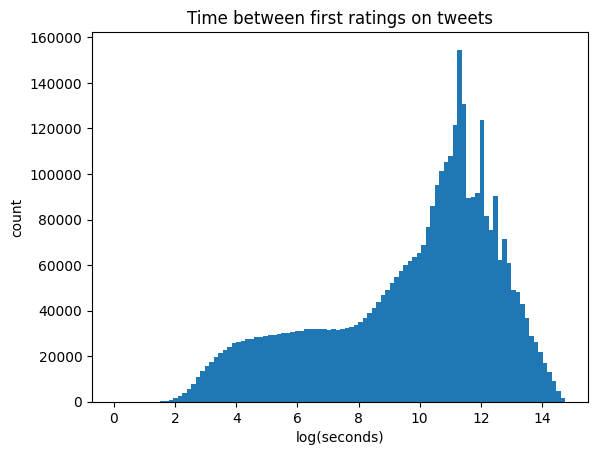

In [5]:
tweet_first["prev_time"] = (
    tweet_first.groupby("raterParticipantId")["ratingCreatedAt"].shift(1)
)

tweet_first["delta_seconds"] = (
    tweet_first["ratingCreatedAt"] - tweet_first["prev_time"]
).dt.total_seconds()

tweet_first["log_delta"] = np.log1p(tweet_first["delta_seconds"])

plt.figure()
plt.hist(tweet_first["log_delta"].dropna(), bins=100)
plt.title("Time between first ratings on tweets")
plt.xlabel("log(seconds)")
plt.ylabel("count")
plt.show()

In [6]:
SESSION_CUTOFF = 600  # 10 minutes

# previous gap
tweet_first["prev_delta_seconds"] = (
    tweet_first["ratingCreatedAt"]
    - tweet_first.groupby("raterParticipantId")["ratingCreatedAt"].shift(1)
).dt.total_seconds()

# next gap
tweet_first["next_delta_seconds"] = (
    tweet_first.groupby("raterParticipantId")["ratingCreatedAt"].shift(-1)
    - tweet_first["ratingCreatedAt"]
).dt.total_seconds()

# session membership
tweet_first["in_session"] = (
    (tweet_first["prev_delta_seconds"] <= SESSION_CUTOFF) |
    (tweet_first["next_delta_seconds"] <= SESSION_CUTOFF)
).fillna(False).astype(int)

# IMPORTANT: x-axis should still use delta_seconds
tweet_first["log_delta_seconds"] = np.log1p(tweet_first["delta_seconds"])

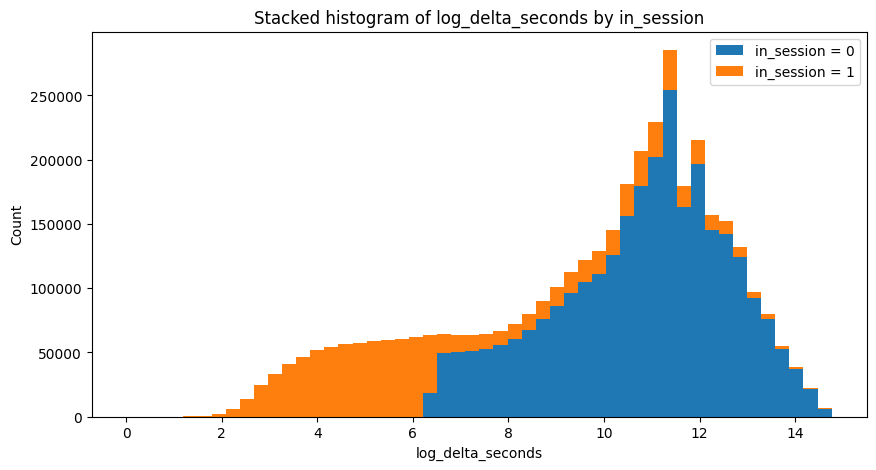

In [7]:
plt.figure(figsize=(10,5))

plt.hist(
    [
        tweet_first.loc[tweet_first["in_session"] == 0, "log_delta_seconds"].dropna(),
        tweet_first.loc[tweet_first["in_session"] == 1, "log_delta_seconds"].dropna()
    ],
    bins=50,
    stacked=True,
    color=["tab:blue", "tab:orange"],
    label=["in_session = 0", "in_session = 1"]
)

plt.title("Stacked histogram of log_delta_seconds by in_session")
plt.xlabel("log_delta_seconds")
plt.ylabel("Count")
plt.legend()
plt.show()

In [8]:
tweet_first["week"] = tweet_first["ratingCreatedAt"].dt.isocalendar().week

sessions_week = (
    tweet_first.groupby(["raterParticipantId", "week"])["session_id"]
    .nunique()
    .reset_index(name="sessions")
)

sessions_week.head()

KeyError: 'Column not found: session_id'

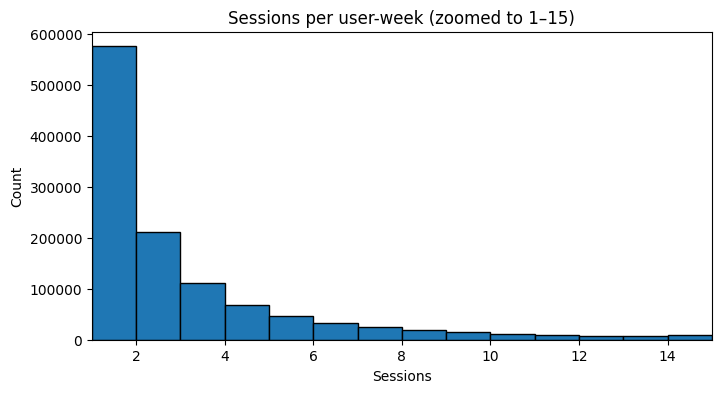

count    1.173766e+06
mean     3.169590e+00
std      4.658364e+00
min      1.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      3.000000e+00
max      1.760000e+02
Name: sessions, dtype: float64

In [ ]:
plt.figure(figsize=(8,4))
plt.hist(sessions_week["sessions"], bins=range(1, 16), edgecolor="black")
plt.title("Sessions per user-week (zoomed to 1–15)")
plt.xlabel("Sessions")
plt.ylabel("Count")
plt.xlim(1, 15)
plt.show()

sessions_week["sessions"].describe()

In [ ]:
def engagement_level(x):
    if x == 1:
        return "not_engaged"
    elif x <= 2:
        return "barely_engaged"
    elif x <= 4:
        return "somewhat_engaged"
    else:
        return "very_engaged"

sessions_week["engagement"] = sessions_week["sessions"].apply(engagement_level)

sessions_week["engagement"].value_counts()

engagement
not_engaged         574950
barely_engaged      211754
very_engaged        208360
somewhat_engaged    178702
Name: count, dtype: int64

In [ ]:
weeks_contributed = (
    sessions_week.groupby("raterParticipantId")["week"]
    .nunique()
    .reset_index(name="weeks_active")
)

def regularity(x):
    if x == 1:
        return "irregular"
    elif x <= 3:
        return "somewhat_regular"
    else:
        return "regular"

weeks_contributed["regularity"] = weeks_contributed["weeks_active"].apply(regularity)

weeks_contributed["regularity"].value_counts()

regularity
irregular           186577
somewhat_regular    171228
regular             126254
Name: count, dtype: int64

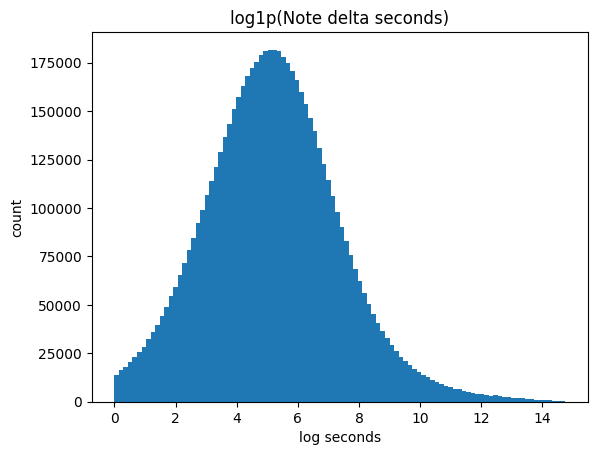

In [ ]:
note_df = df.sort_values(["noteId", "ratingCreatedAt"])

note_df["prev_time"] = note_df.groupby("noteId")["ratingCreatedAt"].shift(1)

note_df["delta_seconds"] = (
    note_df["ratingCreatedAt"] - note_df["prev_time"]
).dt.total_seconds()

note_df["log_delta"] = np.log1p(note_df["delta_seconds"])

plt.figure()
plt.hist(note_df["log_delta"].dropna(), bins=100)
plt.title("log1p(Note delta seconds)")
plt.xlabel("log seconds")
plt.ylabel("count")
plt.show()

In [ ]:
note_df["fast_rating"] = note_df["delta_seconds"] < 7

fast_users = note_df[note_df["fast_rating"]]["raterParticipantId"].unique()

print("Number of users with <7s ratings:", len(fast_users))

Number of users with <7s ratings: 157873


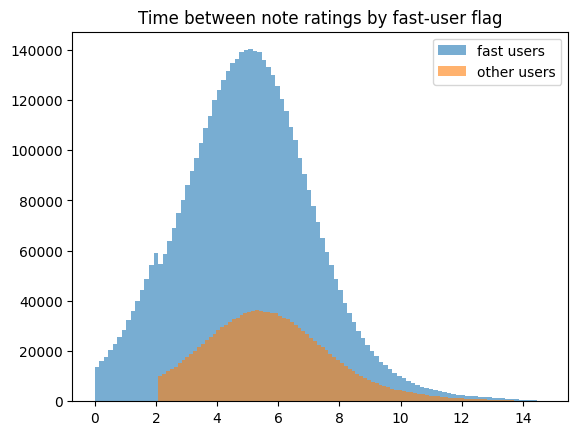

In [ ]:
note_df["fast_user"] = note_df["raterParticipantId"].isin(fast_users)

plt.figure()

plt.hist(
    note_df[note_df["fast_user"]]["log_delta"].dropna(),
    bins=100,
    alpha=0.6,
    label="fast users"
)

plt.hist(
    note_df[~note_df["fast_user"]]["log_delta"].dropna(),
    bins=100,
    alpha=0.6,
    label="other users"
)

plt.legend()
plt.title("Time between note ratings by fast-user flag")
plt.show()

**** Below From Last Week

In [ ]:
def add_session_flags(df_in: pd.DataFrame, gap_seconds: int = 300) -> pd.DataFrame:
    df = df_in.copy()

    prev_time = df.groupby("raterParticipantId")["ratingCreatedAt"].shift(1)
    next_time = df.groupby("raterParticipantId")["ratingCreatedAt"].shift(-1)

    diff_prev = (df["ratingCreatedAt"] - prev_time).dt.total_seconds()
    diff_next = (next_time - df["ratingCreatedAt"]).dt.total_seconds()

    # In-session if near prev or next rating
    df["rating_session"] = ((diff_prev <= gap_seconds) | (diff_next <= gap_seconds)).fillna(False).astype(int)

    # Session end: NOT close to next rating (or no next rating)
    # i.e., this rating is the last rating in a burst
    df["session_end"] = (~(diff_next <= gap_seconds)).fillna(True).astype(int)

    return df


def add_post_interest(df_in: pd.DataFrame) -> pd.DataFrame:
    df = df_in.copy()
    counts = (
        df.groupby(["raterParticipantId", "ratedOnTweetId"])
          .size()
          .rename("post_ratings_by_user")
          .reset_index()
    )
    df = df.merge(counts, on=["raterParticipantId", "ratedOnTweetId"], how="left")
    df["post_interest"] = (df["post_ratings_by_user"] > 1).astype(int)
    return df


def add_swarm_flag(df_in: pd.DataFrame, window: str = "1h", majority: float = 0.5) -> pd.DataFrame:
    """
    Swarm note definition:
      For each note, bucket ratings by time window (e.g., '1h').
      If max(bucket_count / total_count) > majority => swarm note.
    """
    df = df_in.copy()

    # bucket timestamps
    df["time_block"] = df["ratingCreatedAt"].dt.floor(window)

    hour_counts = (
        df.groupby(["noteId", "time_block"])
          .size()
          .rename("block_count")
          .reset_index()
    )
    total_counts = df.groupby("noteId").size().rename("total_count").reset_index()

    tmp = hour_counts.merge(total_counts, on="noteId", how="left")
    tmp["prop_in_block"] = tmp["block_count"] / tmp["total_count"]

    swarm_summary = (
        tmp.groupby("noteId")["prop_in_block"]
           .max()
           .rename("max_prop_in_block")
           .reset_index()
    )
    swarm_summary["rater_swarm"] = (swarm_summary["max_prop_in_block"] > majority).astype(int)

    df = df.merge(swarm_summary[["noteId", "rater_swarm"]], on="noteId", how="left")
    df["rater_swarm"] = df["rater_swarm"].fillna(0).astype(int)
    return df

In [ ]:
base = df.copy()

# Notification flag already exists
base["from_notification"] = base["fromNotification"].fillna(False).astype(int)

# Add engineered flags
base = add_session_flags(base, gap_seconds=300)      # 5 minutes
base = add_post_interest(base)
base = add_swarm_flag(base, window="1h", majority=0.5)

base[["rating_session","session_end","post_interest","from_notification","rater_swarm"]].mean()

rating_session       0.590433
session_end          0.601698
post_interest        0.509207
from_notification    0.019807
rater_swarm          0.022998
dtype: float64

In [ ]:
N = len(base)
summary = pd.DataFrame({
    "pathway": ["rating_session", "post_interest", "from_notification", "rater_swarm"],
    "count": [
        int(base["rating_session"].sum()),
        int(base["post_interest"].sum()),
        int(base["from_notification"].sum()),
        int(base["rater_swarm"].sum()),
    ],
})
summary["percent"] = 100 * summary["count"] / N
summary.sort_values("percent", ascending=False)

,pathway,count,percent
0,rating_session,3837599,59.043300
1,post_interest,3309659,50.920690
3,rater_swarm,149481,2.299837
2,from_notification,128736,1.980665


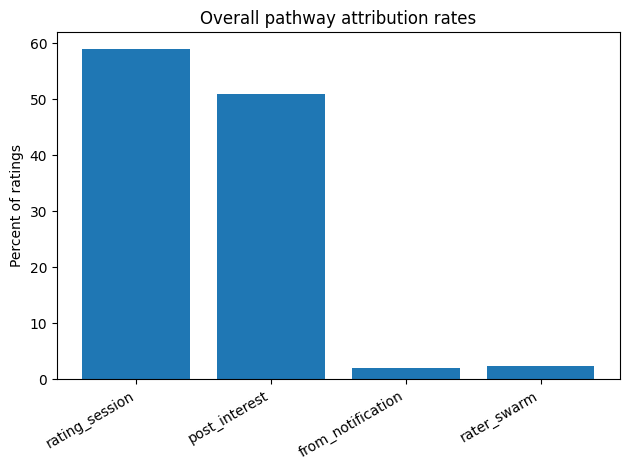

In [ ]:
plt.figure()
plt.bar(summary["pathway"], summary["percent"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Percent of ratings")
plt.title("Overall pathway attribution rates")
plt.tight_layout()
plt.show()

In [ ]:
def overlap_rate(a, b):
    # % of ratings where both flags are 1
    return float(((a == 1) & (b == 1)).mean() * 100)

checks = {
    "session_end & from_notification (%)": overlap_rate(base["session_end"], base["from_notification"]),
    "session_end & rater_swarm (%)": overlap_rate(base["session_end"], base["rater_swarm"]),
    "rater_swarm & from_notification (%)": overlap_rate(base["rater_swarm"], base["from_notification"]),
    "rater_swarm & rating_session (%)": overlap_rate(base["rater_swarm"], base["rating_session"]),
}
checks

{'session_end & from_notification (%)': 1.5642262988613975,
 'session_end & rater_swarm (%)': 1.4832063646650926,
 'rater_swarm & from_notification (%)': 0.02809388527201912,
 'rater_swarm & rating_session (%)': 1.2478854581834211}

In [ ]:
swarm_only = base[base["rater_swarm"] == 1]
{
    "Within swarm: from_notification %": float(swarm_only["from_notification"].mean() * 100) if len(swarm_only) else None,
    "Within swarm: rating_session %": float(swarm_only["rating_session"].mean() * 100) if len(swarm_only) else None,
    "Swarm ratings count": len(swarm_only),
}

{'Within swarm: from_notification %': 1.221559930693533,
 'Within swarm: rating_session %': 54.25973869588777,
 'Swarm ratings count': 149481}

In [ ]:
def run_thresholds(df_base):
    rows = []

    session_gaps = [120, 300, 600]       # 2min, 5min, 10min
    swarm_windows = ["30min", "1h", "2h"]
    swarm_majorities = [0.5, 0.6]        # optional

    # Keep stable parts
    core = df_base.copy()
    core["from_notification"] = core["fromNotification"].fillna(False).astype(int)
    core = add_post_interest(core)

    for gap in session_gaps:
        tmp = add_session_flags(core, gap_seconds=gap)

        for w in swarm_windows:
            for maj in swarm_majorities:
                tmp2 = add_swarm_flag(tmp, window=w, majority=maj)

                rows.append({
                    "session_gap_sec": gap,
                    "swarm_window": w,
                    "swarm_majority": maj,
                    "rating_session_%": round(tmp2["rating_session"].mean() * 100, 2),
                    "session_end&notif_%": round(((tmp2["session_end"]==1) & (tmp2["from_notification"]==1)).mean()*100, 3),
                    "session_end&swarm_%": round(((tmp2["session_end"]==1) & (tmp2["rater_swarm"]==1)).mean()*100, 3),
                    "swarm_%": round(tmp2["rater_swarm"].mean() * 100, 2),
                    "swarm&notif_%": round(((tmp2["rater_swarm"]==1) & (tmp2["from_notification"]==1)).mean()*100, 3),
                    "swarm&session_%": round(((tmp2["rater_swarm"]==1) & (tmp2["rating_session"]==1)).mean()*100, 3),
                })

    return pd.DataFrame(rows)

threshold_table = run_thresholds(df)
threshold_table.head(10)
threshold_table.sort_values(["session_gap_sec", "swarm_window", "swarm_majority"]).head(30)

,session_gap_sec,swarm_window,swarm_majority,rating_session_%,session_end&notif_%,session_end&swarm_%,swarm_%,swarm&notif_%,swarm&session_%
2,120,1h,0.5,55.89,1.621,1.550,2.30,0.028,1.176
3,120,1h,0.6,55.89,1.621,1.018,1.52,0.017,0.781
4,120,2h,0.5,55.89,1.621,4.134,6.22,0.134,3.262
5,120,2h,0.6,55.89,1.621,2.317,3.42,0.052,1.743
0,120,30min,0.5,55.89,1.621,0.737,1.12,0.012,0.583
1,120,30min,0.6,55.89,1.621,0.542,0.84,0.009,0.455
8,300,1h,0.5,59.04,1.564,1.483,2.30,0.028,1.248
9,300,1h,0.6,59.04,1.564,0.974,1.52,0.017,0.828
10,300,2h,0.5,59.04,1.564,3.940,6.22,0.134,3.465
11,300,2h,0.6,59.04,1.564,2.212,3.42,0.052,1.854


In [ ]:
tmp = base.copy()
tmp["month"] = tmp["ratingCreatedAt"].dt.to_period("M").astype(str)

monthly = tmp.groupby("month")[["rating_session","post_interest","from_notification","rater_swarm"]].mean() * 100
monthly = monthly.reset_index()

monthly.tail()

plt.figure()
for col in ["rating_session","post_interest","from_notification","rater_swarm"]:
    plt.plot(monthly["month"], monthly[col], label=col)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Percent of ratings")
plt.title("Pathway attribution over time (monthly)")
plt.legend()
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

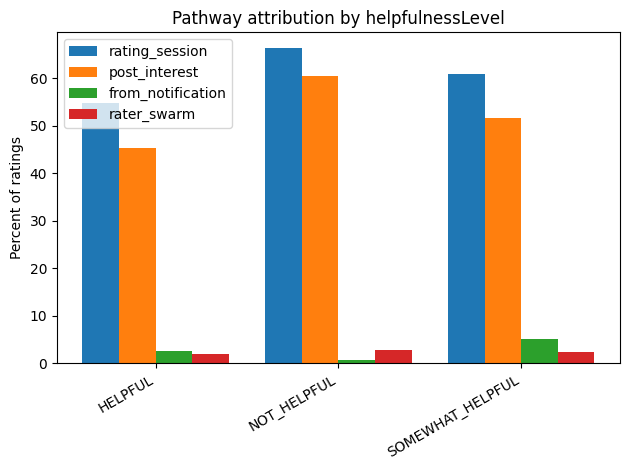

In [ ]:
by_help = base.groupby("helpfulnessLevel")[["rating_session","post_interest","from_notification","rater_swarm"]].mean() * 100
by_help.sort_index()

by_help_plot = by_help.reset_index()

plt.figure()
x = np.arange(len(by_help_plot["helpfulnessLevel"]))
width = 0.2

cols = ["rating_session","post_interest","from_notification","rater_swarm"]
for i, col in enumerate(cols):
    plt.bar(x + i*width, by_help_plot[col], width=width, label=col)

plt.xticks(x + width*1.5, by_help_plot["helpfulnessLevel"], rotation=30, ha="right")
plt.ylabel("Percent of ratings")
plt.title("Pathway attribution by helpfulnessLevel")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
user = base.groupby("raterParticipantId").agg(
    total_ratings=("noteId", "size"),
    p_session=("rating_session", "mean"),
    p_post=("post_interest", "mean"),
    p_notif=("from_notification", "mean"),
    p_swarm=("rater_swarm", "mean"),
).reset_index()

# Convert to percent for readability
for c in ["p_session","p_post","p_notif","p_swarm"]:
    user[c] = user[c] * 100

user["max_pathway_pct"] = user[["p_session","p_post","p_notif","p_swarm"]].max(axis=1)

# simple “single vs mixed” rule
user["single_pathway_user"] = (user["max_pathway_pct"] >= 80).astype(int)

user[["total_ratings","max_pathway_pct","single_pathway_user"]].describe()

,total_ratings,max_pathway_pct,single_pathway_user
count,484059.000000,484059.000000,484059.000000
mean,13.427361,35.293097,0.157431
std,40.563715,36.117524,0.364207
min,1.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000
50%,4.000000,30.000000,0.000000
75%,11.000000,66.666667,0.000000
max,4028.000000,100.000000,1.000000


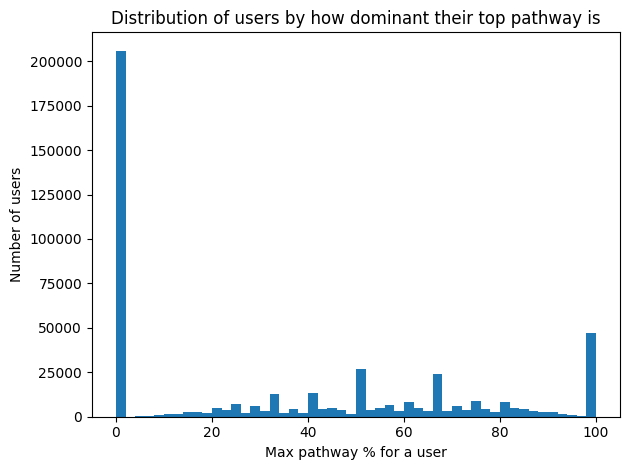

Percent of users mostly single-pathway (>=80%): 15.74


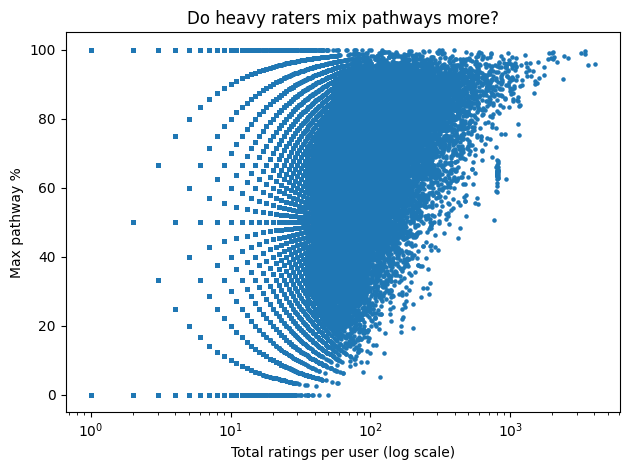

In [ ]:
plt.figure()
plt.hist(user["max_pathway_pct"], bins=50)
plt.xlabel("Max pathway % for a user")
plt.ylabel("Number of users")
plt.title("Distribution of users by how dominant their top pathway is")
plt.tight_layout()
plt.show()

print("Percent of users mostly single-pathway (>=80%):", round(user["single_pathway_user"].mean()*100, 2))

plt.figure()
plt.scatter(user["total_ratings"], user["max_pathway_pct"], s=5)
plt.xscale("log")
plt.xlabel("Total ratings per user (log scale)")
plt.ylabel("Max pathway %")
plt.title("Do heavy raters mix pathways more?")
plt.tight_layout()
plt.show()

## Answers

### 1) Do these attributions capture the behavior we care about?

**Overall plausibility**

Using the default thresholds (5-minute session gap, 1-hour swarm window, majority = 0.5), the share of ratings attributed to each pathway is:

- rating_session: **59.0%**
- post_interest: **50.9%**
- from_notification: **2.0%**
- rater_swarm: **2.3%**

Because these are overlapping flags, a rating may belong to multiple pathways. The magnitudes look reasonable: many ratings occur in bursts or involve multiple notes on the same tweet, while notifications and swarm behavior are relatively rare.

**Conflict / overlap checks**

Potentially problematic overlaps were small:

- session_end & from_notification: **1.56%**
- session_end & rater_swarm: **1.48%**
- rater_swarm & from_notification: **0.03%**
- rater_swarm & rating_session: **1.25%**

Within swarm ratings:
- from_notification: **1.22%**
- rating_session: **54.3%**

Swarm ratings count: **149,481**

These overlaps are small relative to the dataset. The fact that many swarm ratings are also part of sessions is expected, since swarms represent bursts of activity.

**Threshold robustness**

I tested alternative thresholds:

- session_gap_sec: **120, 300, 600** seconds
- swarm_window: **30min, 1h, 2h**
- swarm_majority: **0.5, 0.6**

Results were generally stable:
- Session attribution ranges from **~56% (2 min)** to **~61% (10 min)**.
- Swarm attribution ranges from **~1% (30 min)** to **~6% (2 h)**.
- Overlap rates remain low.

Because conclusions do not depend heavily on the exact cutoffs, I retain **5 minutes** for sessions and **1 hour / 50% majority** for swarms as a reasonable balance.

---

### 2) To what extent are ratings created using each pathway?

**Overall proportions**

Using the default thresholds:

- ~**59%** of ratings occur in rating sessions.
- ~**51%** show post-interest (multiple notes on the same tweet).
- ~**2%** come from notifications.
- ~**2.3%** occur on swarm notes.

Sessions and post-interest are common but not universal, while notifications and swarms are rare but non-negligible.

**By time**

Monthly breakdowns show that pathway proportions are **relatively stable over time**, with no month where a single pathway dominates or disappears.

**By helpfulness level**

Across HELPFUL, NOT_HELPFUL, and NEEDS_MORE_RATINGS notes, the same general pattern holds: sessions and post-interest are common, while notifications and swarms remain small. Differences across statuses are modest and no pathway is uniquely tied to one outcome.

---

### 3) To what extent do individual users mix pathways?

**User-level pathway mix**

For each user I calculated the share of their ratings coming from each pathway. The typical user has **4 ratings**, with a long tail of highly active raters.

- Average **max pathway share**: ~**35%**
- **~15.7%** of users are mostly single-pathway users (≥80% of ratings from one pathway)
- **~84%** of users show a mixed pathway profile

**Heavy vs. light raters**

Higher-volume raters tend to have **lower maximum pathway shares**, meaning their ratings are spread across multiple pathways. Low-volume users often appear single-pathway simply because they have few ratings.

Overall, most users engage with Community Notes through **multiple pathways rather than a single consistent mechanism**.

## User trajectory plots

In [14]:
note_traj = pd.read_parquet("../../data/Archive/sample_user_note_traj.parquet")
rating_traj = pd.read_parquet("../../data/Archive/sample_user_rating_traj.parquet")
request_traj = pd.read_parquet("../../data/Archive/sample_user_request_traj.parquet")

In [15]:
notes_small = note_traj[["noteAuthorParticipantId", "userMonth", "calendarMonth", "notesCreated"]].rename(
    columns={"noteAuthorParticipantId": "userId"}
)

ratings_small = rating_traj[["raterParticipantId", "userMonth", "calendarMonth", "notesRated"]].rename(
    columns={"raterParticipantId": "userId"}
)

requests_small = request_traj[["requesterParticipantId", "userMonth", "calendarMonth", "requestsMade"]].rename(
    columns={"requesterParticipantId": "userId"}
)

In [16]:
traj = (
    ratings_small
    .merge(notes_small, on=["userId", "userMonth", "calendarMonth"], how="outer")
    .merge(requests_small, on=["userId", "userMonth", "calendarMonth"], how="outer")
    .fillna(0)
)

traj[["notesRated", "notesCreated", "requestsMade"]] = traj[
    ["notesRated", "notesCreated", "requestsMade"]
].astype(int)

In [17]:
traj["dominantType"] = traj[["notesRated", "notesCreated", "requestsMade"]].idxmax(axis=1)

traj["dominantType"] = traj["dominantType"].replace({
    "notesRated": "Rating",
    "notesCreated": "Writing",
    "requestsMade": "Requesting"
})

In [18]:
dominant_share = (
    traj.groupby(["userMonth", "dominantType"])
    .size()
    .reset_index(name="numUsers")
)

dominant_share["pctUsers"] = (
    dominant_share["numUsers"]
    / dominant_share.groupby("userMonth")["numUsers"].transform("sum")
) * 100

dominant_pivot = dominant_share.pivot(
    index="userMonth",
    columns="dominantType",
    values="pctUsers"
).fillna(0)

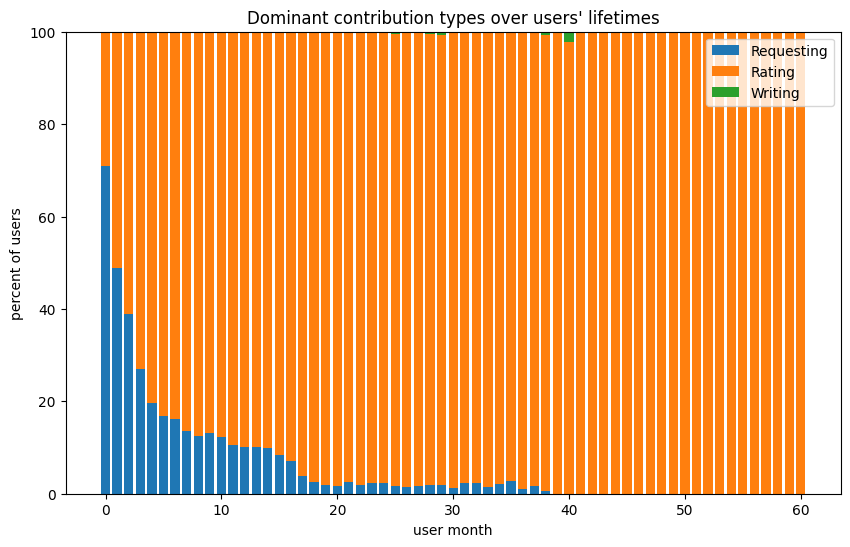

In [20]:
dominant_pivot = dominant_pivot.reindex(columns=["Requesting", "Rating", "Writing"], fill_value=0)

plt.figure(figsize=(10, 6))

plt.bar(dominant_pivot.index, dominant_pivot["Requesting"], label="Requesting")
plt.bar(
    dominant_pivot.index,
    dominant_pivot["Rating"],
    bottom=dominant_pivot["Requesting"],
    label="Rating"
)
plt.bar(
    dominant_pivot.index,
    dominant_pivot["Writing"],
    bottom=dominant_pivot["Requesting"] + dominant_pivot["Rating"],
    label="Writing"
)

plt.title("Dominant contribution types over users' lifetimes")
plt.xlabel("user month")
plt.ylabel("percent of users")
plt.legend()
plt.show()